## Dataset loading

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, Subset
from sklearn.model_selection import train_test_split
import numpy as np
from numpy.fft import fft, fftfreq, fftshift

FS = 14e6

class DroneSignalsDataset(Dataset):
    def __init__(self, x_iq_tensor, x_spec_tensor, y_tensor, snr_tensor, duty_cycle_tensor):
        self.x_iq = x_iq_tensor
        self.x_spec = x_spec_tensor
        self.y = y_tensor
        self.snr = snr_tensor
        self.duty_cycle = duty_cycle_tensor

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x_iq[idx], self.x_spec[idx], self.y[idx], self.snr[idx], self.duty_cycle[idx]   


dataset_folder = './sig_data/'

dataset_stats = pd.read_csv(dataset_folder + 'class_stats.csv', index_col=0)
class_names = dataset_stats['class'].values

snr_stats = pd.read_csv(dataset_folder + 'SNR_stats.csv', index_col=0)
snr_list = snr_stats['SNR'].values

# load data
dataset_dict = torch.load(dataset_folder + 'dataset.pt')

x_iq = dataset_dict['x_iq']
x_spec = dataset_dict['x_spec']
y = dataset_dict['y']
snrs = dataset_dict['snr']
duty_cycle = dataset_dict['duty_cycle']


# create pytorch dataset form tensors
dataset = DroneSignalsDataset(x_iq,x_spec,y,snrs,duty_cycle)
del(x_iq, y, snrs, duty_cycle, dataset_dict)

data_loader = torch.utils.data.DataLoader(
    dataset=dataset,
    batch_size=64,
    shuffle=True
)

## CNN Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DroneCNN(nn.Module):
    def __init__(self, num_classes):
        super(DroneCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(2, 16, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 *  (x_spec.shape[2] // 8) * (x_spec.shape[3] // 8), 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x_spec):
        x = F.relu(self.bn1(self.conv1(x_spec)))
        x = self.pool1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x


## Training Loop

In [ ]:
from torch.utils.data import DataLoader, random_split
total_len = len(dataset)
train_len = int(0.8 * total_len)
val_len   = int(0.1 * total_len)
test_len  = total_len - train_len - val_len

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_len, val_len, test_len])


batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [28]:
# Model, Loss, Optimizer
num_classes = len(class_names)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training with: {device}")


model = DroneCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def evaluate(model, val_loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for x_iq, x_spec, y, snr, duty in val_loader:
            x_spec, y = x_spec.to(device), y.to(device)
            if x_spec.dim() == 3:
                x_spec = x_spec.unsqueeze(1)
            
            outputs = model(x_spec)
            loss = criterion(outputs, y)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()
    
    avg_loss = running_loss / len(val_loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


# Training loop
for epoch in range(10):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for x_iq, x_spec, y, snr, duty in train_loader:
        x_spec, y = x_spec.to(device), y.to(device)
        if x_spec.dim() == 3:
            x_spec = x_spec.unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(x_spec)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()
    
    acc = 100. * correct / total
    train_loss = running_loss / len(train_loader)



    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    
    print(f"Epoch {epoch+1}, "
          f"Train Loss: {train_loss:.4f}, Train Acc: {acc:.2f}%, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")


SAVE_MODEL = True

if SAVE_MODEL:
    torch.save(model.state_dict(), "models/CNN_model_weights.pth")


Training with: cuda
Epoch 1, Train Loss: 0.9524, Train Acc: 71.70%, Val Loss: 0.6182, Val Acc: 81.88%
Epoch 2, Train Loss: 0.6208, Train Acc: 81.26%, Val Loss: 0.5139, Val Acc: 85.24%
Epoch 3, Train Loss: 0.5120, Train Acc: 84.82%, Val Loss: 0.4688, Val Acc: 87.85%
Epoch 4, Train Loss: 0.4453, Train Acc: 87.03%, Val Loss: 0.3833, Val Acc: 90.25%
Epoch 5, Train Loss: 0.4068, Train Acc: 88.37%, Val Loss: 0.3900, Val Acc: 90.00%
Epoch 6, Train Loss: 0.3750, Train Acc: 89.40%, Val Loss: 0.4083, Val Acc: 90.16%
Epoch 7, Train Loss: 0.3430, Train Acc: 90.21%, Val Loss: 0.3796, Val Acc: 90.83%
Epoch 8, Train Loss: 0.3257, Train Acc: 90.83%, Val Loss: 0.3499, Val Acc: 91.45%
Epoch 9, Train Loss: 0.2984, Train Acc: 91.44%, Val Loss: 0.3376, Val Acc: 91.75%
Epoch 10, Train Loss: 0.2809, Train Acc: 91.76%, Val Loss: 0.3169, Val Acc: 92.12%


CNN Accuracy: 0.9251342315874784
              precision    recall  f1-score   support

         DJI       0.97      0.66      0.79       211
   FutabaT14       0.98      0.79      0.87       704
    FutabaT7       0.93      0.69      0.79       340
    Graupner       0.99      0.89      0.94       666
       Noise       0.89      0.99      0.94      5288
     Taranis       0.99      0.94      0.96      1628
     Turnigy       0.93      0.80      0.86      1034

    accuracy                           0.93      9871
   macro avg       0.95      0.82      0.88      9871
weighted avg       0.93      0.93      0.92      9871



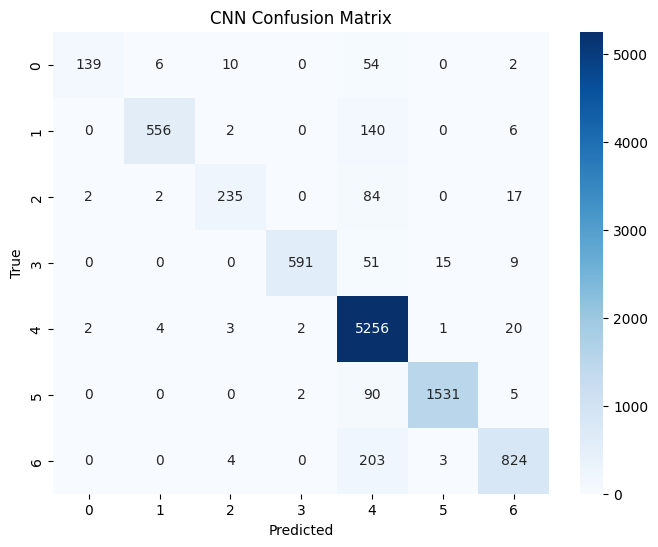

In [29]:
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for x_iq, x_spec, y, snr, duty in test_loader:
        x_spec = x_spec.to(device)
        y = y.to(device)

        outputs = model(x_spec)               
        preds = torch.argmax(outputs, dim=1)       

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("CNN Accuracy:", accuracy_score(y_true, y_pred))

# Precision, Recall, F1-score
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("CNN Confusion Matrix")
plt.show()